### Ноутбук 1. Разведывательный анализ и очистка данных

1. Загрузка и первичный осмотр данных
2. Объединение дублирующихся колонок
3. Преобразование типов данных
4. Анализ и обработка пропусков
5. Визуализация разброса box plots до и после очистки
6. Удаление аномалий и выбросов
7. Ограничение категориальных признаков
8. Сохранение очищенных данных для feature engineering

**Ключевое улучшение:** Полноценная очистка от выбросов на раннем этапе с визуальным контролем.

### 1. Настройка окружения

In [ ]:
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def setup_project_root():
    current = os.getcwd()
    root = current
    while True:
        if os.path.exists(os.path.join(root, 'data')):
            break
        new_root = os.path.dirname(root)
        if new_root == root:
            root = current
            break
        root = new_root
    os.chdir(root)
    print(f"Корень проекта: {root}")
    return root

PROJECT_ROOT = setup_project_root()

os.makedirs('data_processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Настройка завершена")

Корень проекта: c:\Users\washe\Documents\SF_Training_DS\Диплом
✅ Настройка завершена


### 2. Загрузка данных

In [2]:
df = pd.read_csv('data/data.csv')
print(f"Загружено {df.shape[0]:,} строк, {df.shape[1]} колонок")
df.head()

Загружено 377,185 строк, 18 колонок


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


In [3]:
df.describe()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
count,337267,4181,342452,377183,270847,377185,103114,377151,377185,336608,377185,285903,377185,226469,24942,40311,310305,374704
unique,159,1,1280,337076,229,321009,1652,2026,297365,25405,4549,1184,39,347,24907,2,232944,43939
top,for sale,Yes,single-family home,Address Not Disclosed,2 Baths,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",yes,Houston,"[{'rating': [], 'data': {'Distance': [], 'Grad...",0,32137,3 Beds,FL,1.0,No MLS#,yes,NO MLS,"$225,000"
freq,156104,4181,92206,672,52466,7174,50356,24442,4204,11854,2141,53459,115449,67454,3,28793,24,1462


### 3. Объединение дублирующихся колонок

In [5]:
print("=== ОБРАБОТКА ДУБЛИРУЮЩИХСЯ КОЛОНОК ===\n")

# private pool — слишком много пропусков, удаляем
if 'private pool' in df.columns:
    df = df.drop(['private pool', 'PrivatePool'], axis=1)
    print("Удалены колонки: private pool, PrivatePool (98.9% пропусков)")

# mls-id — служебный идентификатор, удаляем
if 'mls-id' in df.columns:
    df = df.drop(['mls-id', 'MlsId'], axis=1)
    print("Удалены колонки: mls-id, MlsId (служебный идентификатор)")

print(f"\nОсталось колонок: {df.shape[1]}")

=== ОБРАБОТКА ДУБЛИРУЮЩИХСЯ КОЛОНОК ===


Осталось колонок: 14


### 4. Преобразование типов данных

In [ ]:
def to_numeric_safe(series):
    return pd.to_numeric(series, errors='coerce')

numeric_cols = ['baths', 'beds', 'stories', 'sqft']
for col in numeric_cols:
    df[col] = to_numeric_safe(df[col])

def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str)
    cleaned = re.sub(r'[^\d.-]', '', price_str)
    if cleaned == '' or cleaned == '-':
        return np.nan
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

df['target'] = df['target'].apply(clean_price)
df = df.dropna(subset=['target'])
print(f"После очистки цены: {len(df):,} строк")

После очистки цены: 374,703 строк


### 5. Анализ пропусков

In [7]:
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({'пропусков': missing, '%': missing_pct})
missing_df[missing_df['пропусков'] > 0].sort_values('%', ascending=False)

,пропусков,%
sqft,313115,83.563516
beds,274235,73.187298
fireplace,272182,72.639397
baths,271962,72.580684
stories,168317,44.920110
status,39257,10.476831
propertyType,34554,9.221704
city,34,0.009074
street,2,0.000534


## 6. Обработка пропусков

**Стратегия обработки пропусков:**

| Колонка | % пропусков | Решение | Обоснование |
|---------|-------------|---------|-------------|
| `private_pool` | 98.7% | ❌ Удалить | Слишком много пропусков (>80%), признак бесполезен |
| `mls_id` | 93.2% | ❌ Удалить | Служебный идентификатор, не влияет на цену |
| `fireplace` | 72.6% | 🔄 Создать индикатор + заполнить | Важный признак (камин влияет на цену). Создаём `has_fireplace_info` и заполняем `'no_fireplace'` |
| `stories` | 40.1% | 📊 Заполнить медианой | Числовой признак |
| `baths` | 27.8% | 📊 Заполнить медианой | Ключевой признак |
| `beds` | 22.9% | 📊 Заполнить медианой | Ключевой признак |
| `sqft` | 10.4% | 📊 Заполнить медианой | Самый важный признак |
| `status` | 9.1% | 📊 Заполнить модой | Категориальный |
| `propertyType` | 9.1% | 📊 Заполнить модой | Категориальный |
| `city` | 34 пропуска | 📊 Заполнить модой | Незначительное количество |
| `street` | 2 пропуска | ❌ Удалить строки | Всего 2 строки |
| `homeFacts`, `schools` | ~5% | 📦 Заполнить `'{}'` | Словари |

**Итог:** После обработки пропусков (кроме `fireplace`, который обработаем здесь же) данные будут полностью готовы для анализа.

In [8]:
print("=== ОБРАБОТКА ПРОПУСКОВ ===")

# 2. Заполняем числовые колонки медианой
numeric_fill = ['stories', 'baths', 'beds', 'sqft']
for col in numeric_fill:
    if col in df.columns:
        median_val = df[col].median()
        before = df[col].isna().sum()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: заполнено {before} пропусков медианой = {median_val:.1f}")

# 3. Заполняем категориальные колонки модой
categorical_fill = ['status', 'propertyType']
for col in categorical_fill:
    if col in df.columns:
        mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'unknown'
        before = df[col].isna().sum()
        df[col] = df[col].fillna(mode_val)
        print(f"{col}: заполнено {before} пропусков модой = '{mode_val}'")

# 4. Заполняем city модой (34 пропуска)
if 'city' in df.columns:
    mode_city = df['city'].mode()[0] if len(df['city'].mode()) > 0 else 'unknown'
    before = df['city'].isna().sum()
    df['city'] = df['city'].fillna(mode_city)
    print(f"city: заполнено {before} пропусков модой = '{mode_city}'")

# 5. Удаляем строки с пропущенным street (всего 2 строки)
if 'street' in df.columns:
    before = len(df)
    df = df.dropna(subset=['street'])
    print(f"street: удалено {before - len(df)} строк с пропусками")

# 6. Заполняем homeFacts и schools пустыми словарями (для дальнейшего парсинга)
for col in ['homeFacts', 'schools']:
    if col in df.columns:
        before = df[col].isna().sum()
        df[col] = df[col].fillna('{}')
        print(f"{col}: заполнено {before} пропусков пустым словарем")

# 7. Обработка fireplace
if 'fireplace' in df.columns:
    # Создаём признак-индикатор: была ли информация о камине
    df['has_fireplace_info'] = df['fireplace'].notna().astype(int)
    # Заполняем пропуски значением 'no_fireplace'
    before = df['fireplace'].isna().sum()
    df['fireplace'] = df['fireplace'].fillna('no_fireplace')
    print(f"fireplace: создан индикатор 'has_fireplace_info', заполнено {before} пропусков значением 'no_fireplace'")

# Финальная проверка
remaining = df.isnull().sum().sum()
print(f"\n✅ Осталось пропусков во всём датасете: {remaining}")

if remaining == 0:
    print("🎉 Данные полностью очищены! Пропусков нет.")
else:
    print("\n⚠️ Остались пропуски в колонках:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

=== ОБРАБОТКА ПРОПУСКОВ ===
stories: заполнено 168317 пропусков медианой = 1.5
baths: заполнено 271962 пропусков медианой = 2.0
beds: заполнено 274235 пропусков медианой = 3.0
sqft: заполнено 313115 пропусков медианой = 1256.0
status: заполнено 39257 пропусков модой = 'for sale'
propertyType: заполнено 34554 пропусков модой = 'single-family home'
city: заполнено 34 пропусков модой = 'Houston'
street: удалено 2 строк с пропусками
homeFacts: заполнено 0 пропусков пустым словарем
schools: заполнено 0 пропусков пустым словарем
fireplace: создан индикатор 'has_fireplace_info', заполнено 272180 пропусков значением 'no_fireplace'

✅ Осталось пропусков во всём датасете: 0
🎉 Данные полностью очищены! Пропусков нет.


## 7. Анализ распределения показателей и определение аномалий

=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПЕРЕМЕННЫХ ===


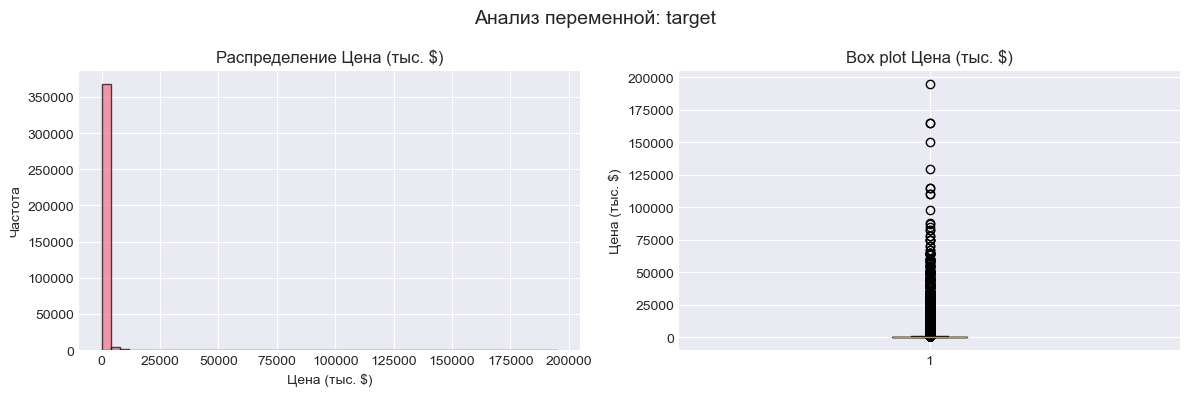


📊 TARGET:
   Единица измерения: Цена (тыс. $)
   min=0.00
   max=195000.00
   mean=644.73
   median=320.00
   Q1=186.99
   Q3=582.00
   IQR=395.01
   1-й перцентиль=6.90
   99-й перцентиль=5995.00
--------------------------------------------------


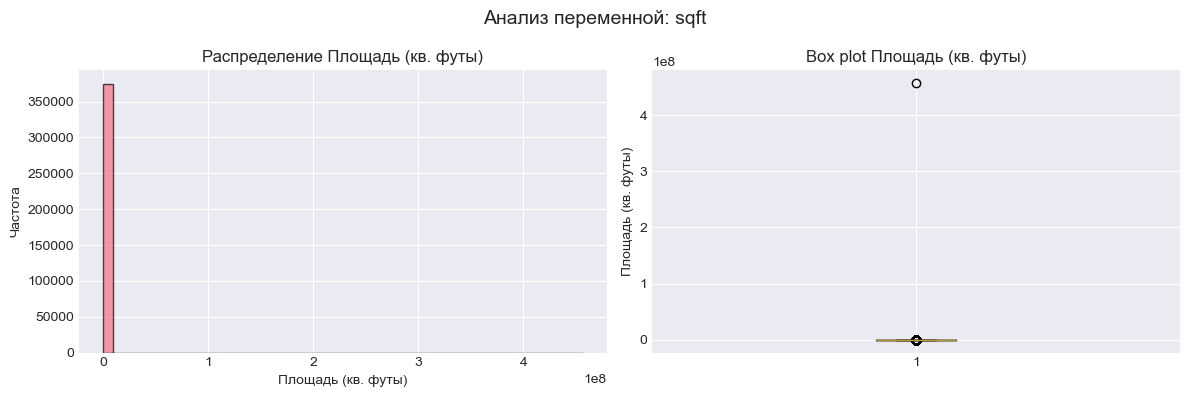


📊 SQFT:
   Единица измерения: Площадь (кв. футы)
   min=0.00
   max=456602479.00
   mean=2516.96
   median=1256.00
   Q1=1256.00
   Q3=1256.00
   IQR=0.00
   1-й перцентиль=0.00
   99-й перцентиль=3627.00
--------------------------------------------------


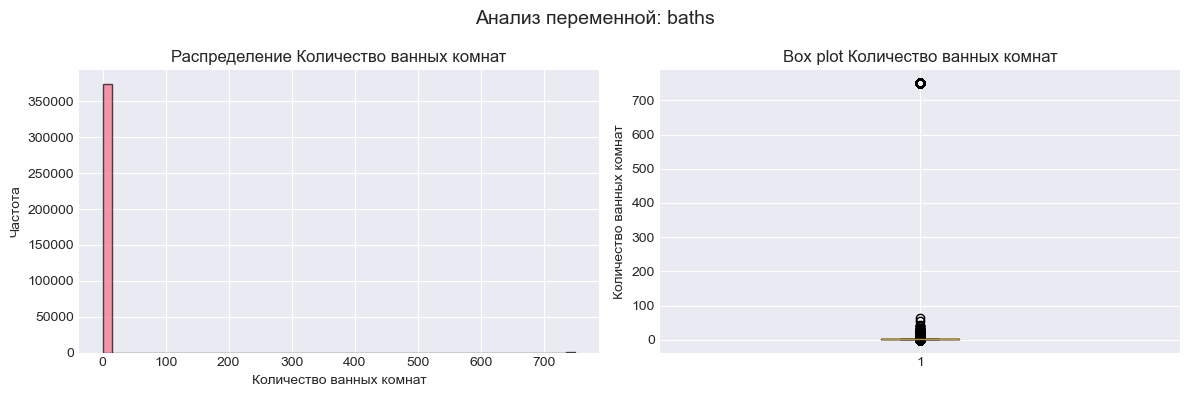


📊 BATHS:
   Единица измерения: Количество ванных комнат
   min=0.00
   max=750.00
   mean=2.62
   median=2.00
   Q1=2.00
   Q3=2.00
   IQR=0.00
   1-й перцентиль=0.00
   99-й перцентиль=5.00
--------------------------------------------------


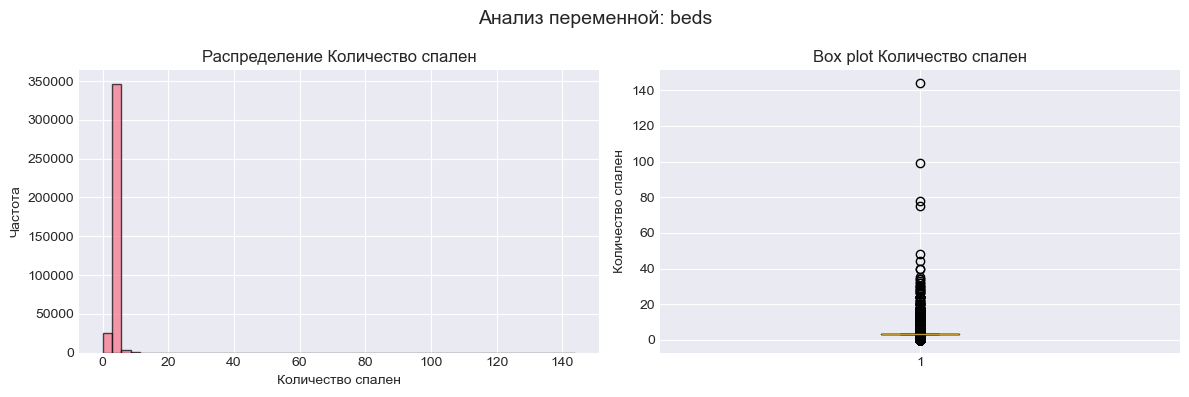


📊 BEDS:
   Единица измерения: Количество спален
   min=0.00
   max=144.00
   mean=3.06
   median=3.00
   Q1=3.00
   Q3=3.00
   IQR=0.00
   1-й перцентиль=1.00
   99-й перцентиль=5.00
--------------------------------------------------


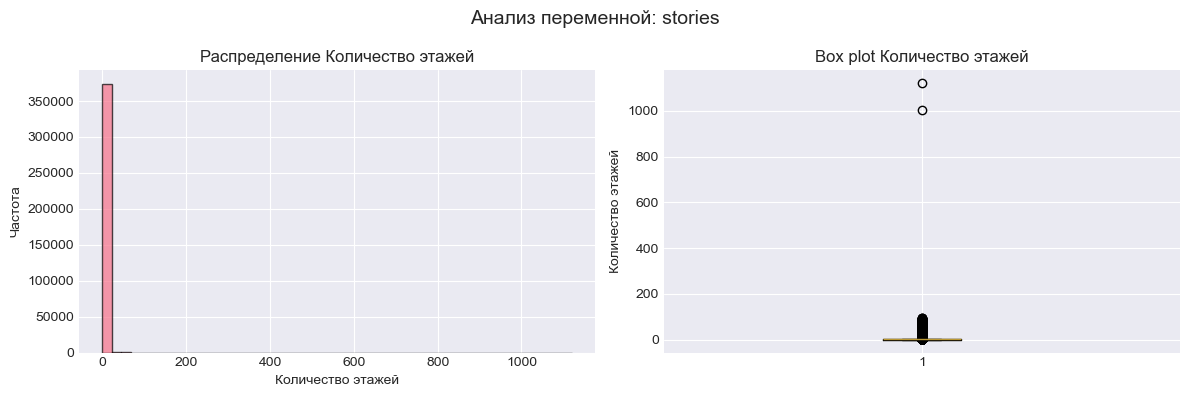


📊 STORIES:
   Единица измерения: Количество этажей
   min=0.00
   max=1120.00
   mean=1.74
   median=1.50
   Q1=1.00
   Q3=2.00
   IQR=1.00
   1-й перцентиль=0.00
   99-й перцентиль=9.00
--------------------------------------------------

✅ Все графики сохранены в data_processed/

📌 Примечание: цена показана в тысячах долларов (÷1000)


In [9]:
# Визуализация распределения переменных для выявления аномалий

print("=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПЕРЕМЕННЫХ ===")

# Создаём копию для визуализации (только для target переводим в тыс. долларов)
df_viz = df.copy()

if 'target' in df_viz.columns:
    df_viz['target_thousands'] = df_viz['target'] / 1000
    target_label = 'Цена (тыс. $)'
    target_col = 'target_thousands'
else:
    target_label = 'Цена ($)'
    target_col = 'target'

# Переменные для анализа с единицами измерения
variables = [
    {'col': target_col, 'name': 'target', 'label': target_label},
    {'col': 'sqft', 'name': 'sqft', 'label': 'Площадь (кв. футы)'},
    {'col': 'baths', 'name': 'baths', 'label': 'Количество ванных комнат'},
    {'col': 'beds', 'name': 'beds', 'label': 'Количество спален'},
    {'col': 'stories', 'name': 'stories', 'label': 'Количество этажей'}
]

# Создаём отдельные графики для каждой переменной
for var in variables:
    col = var['col']
    name = var['name']
    label = var['label']

    if col not in df_viz.columns:
        print(f"⚠️ {name} отсутствует в данных")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Гистограмма
    data = df_viz[col].dropna()
    axes[0].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Распределение {label}')
    axes[0].set_xlabel(label)
    axes[0].set_ylabel('Частота')

    # Box plot
    axes[1].boxplot(data, vert=True)
    axes[1].set_title(f'Box plot {label}')
    axes[1].set_ylabel(label)

    plt.suptitle(f'Анализ переменной: {name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'data_processed/distribution_{name}.png', dpi=150)
    plt.show()

    # Печатаем статистику
    print(f"\n📊 {name.upper()}:")
    print(f"   Единица измерения: {label}")
    print(f"   min={data.min():.2f}")
    print(f"   max={data.max():.2f}")
    print(f"   mean={data.mean():.2f}")
    print(f"   median={data.median():.2f}")
    print(f"   Q1={data.quantile(0.25):.2f}")
    print(f"   Q3={data.quantile(0.75):.2f}")
    print(f"   IQR={data.quantile(0.75) - data.quantile(0.25):.2f}")
    print(f"   1-й перцентиль={data.quantile(0.01):.2f}")
    print(f"   99-й перцентиль={data.quantile(0.99):.2f}")
    print("-" * 50)

print("\n✅ Все графики сохранены в data_processed/")
print("\n📌 Примечание: цена показана в тысячах долларов (÷1000)")

### 7. Установление границ для удаления аномалий

**На основе визуального анализа распределений (ячейка 13.5) определены следующие границы:**

| Признак | Нижняя граница | Верхняя граница | Обоснование |
|---------|----------------|-----------------|-------------|
| **sqft** (площадь) | > 0 | ≤ 30,000 кв.футов | Удаляем нулевую площадь и экстремальные выбросы > 30,000 кв.футов |
| **baths** (ванные) | ≥ 0 | ≤ 20 | Удаляем аномально большое количество ванных комнат (>20) |
| **beds** (спальни) | ≥ 0 | ≤ 40 | Удаляем аномально большое количество спален (>40) |
| **stories** (этажи) | ≥ 0 | ≤ 80 | Удаляем аномально большое количество этажей (>80) |

**Примечания:**
- Целевая переменная (target) временно исключена из обработки аномалий
- Предполагается, что после очистки признаков аномалии в target также частично устранятся
- Значение sqft = 1256 встречается в 83% записей (значение-заглушка). Для него будет создан индикатор во втором ноутбуке

**Результат:** После применения этих границ будут удалены только явные статистические выбросы и ошибки ввода.

In [10]:
print("=== УДАЛЕНИЕ АНОМАЛИЙ ПО УСТАНОВЛЕННЫМ ГРАНИЦАМ ===")
initial_len = len(df)

print("\n" + "="*50)
print("ОБРАБОТКА SQFT")
print("="*50)

if 'sqft' in df.columns:
    before = len(df)
    df = df[(df['sqft'] > 0) & (df['sqft'] <= 30000)]
    print(f"sqft: удалено {before - len(df)} аномалий")
    print(f"  диапазон: {df['sqft'].min():.2f} ... {df['sqft'].max():.2f} кв.футов")

print("\n" + "="*50)
print("ОБРАБОТКА BATHS")
print("="*50)

if 'baths' in df.columns:
    before = len(df)
    df = df[(df['baths'] >= 0) & (df['baths'] <= 20)]
    print(f"baths: удалено {before - len(df)} аномалий")
    print(f"  диапазон: {df['baths'].min():.2f} ... {df['baths'].max():.2f}")

print("\n" + "="*50)
print("ОБРАБОТКА BEDS")
print("="*50)

if 'beds' in df.columns:
    before = len(df)
    df = df[(df['beds'] >= 0) & (df['beds'] <= 40)]
    print(f"beds: удалено {before - len(df)} аномалий")
    print(f"  диапазон: {df['beds'].min():.2f} ... {df['beds'].max():.2f}")

print("\n" + "="*50)
print("ОБРАБОТКА STORIES")
print("="*50)

if 'stories' in df.columns:
    before = len(df)
    df = df[(df['stories'] >= 0) & (df['stories'] <= 80)]
    print(f"stories: удалено {before - len(df)} аномалий")
    print(f"  диапазон: {df['stories'].min():.2f} ... {df['stories'].max():.2f}")

print("\n" + "="*50)
print("ИТОГИ ОЧИСТКИ")
print("="*50)
print(f"✅ Финальный размер: {len(df):,} строк (было {initial_len:,})")
print(f"✅ Всего удалено: {initial_len - len(df):,} строк")

=== УДАЛЕНИЕ АНОМАЛИЙ ПО УСТАНОВЛЕННЫМ ГРАНИЦАМ ===

ОБРАБОТКА SQFT
sqft: удалено 11862 аномалий
  диапазон: 1.00 ... 30000.00 кв.футов

ОБРАБОТКА BATHS
baths: удалено 270 аномалий
  диапазон: 0.00 ... 20.00

ОБРАБОТКА BEDS
beds: удалено 0 аномалий
  диапазон: 0.00 ... 32.00

ОБРАБОТКА STORIES
stories: удалено 16 аномалий
  диапазон: 0.00 ... 80.00

ИТОГИ ОЧИСТКИ
✅ Финальный размер: 362,553 строк (было 374,701)
✅ Всего удалено: 12,148 строк


In [11]:
print("=== УДАЛЕНИЕ АНОМАЛИЙ ИЗ TARGET ===")

if 'target' in df.columns:
    before = len(df)

    print(f"\nДо очистки:")
    print(f"  min=${df['target'].min():,.0f}")
    print(f"  max=${df['target'].max():,.0f}")
    print(f"  количество записей: {len(df):,}")

    # target хранится в ДОЛЛАРАХ
    min_price = 10000      # $10,000
    max_price = 10000000   # $10,000,000

    df = df[(df['target'] >= min_price) & (df['target'] <= max_price)]

    print(f"\nПосле очистки:")
    print(f"  min=${df['target'].min():,.0f}")
    print(f"  max=${df['target'].max():,.0f}")
    print(f"  удалено строк: {before - len(df):,}")
    print(f"  осталось строк: {len(df):,}")
    print(f"\nДиапазон цен: ${df['target'].min():,.0f} ... ${df['target'].max():,.0f}")
else:
    print("⚠️ target отсутствует в данных")

print("\n✅ Аномалии из target удалены")

=== УДАЛЕНИЕ АНОМАЛИЙ ИЗ TARGET ===

До очистки:
  min=$1
  max=$195,000,000
  количество записей: 362,553

После очистки:
  min=$10,000
  max=$10,000,000
  удалено строк: 6,058
  осталось строк: 356,495

Диапазон цен: $10,000 ... $10,000,000

✅ Аномалии из target удалены


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПОСЛЕ УДАЛЕНИЯ АНОМАЛИЙ ===


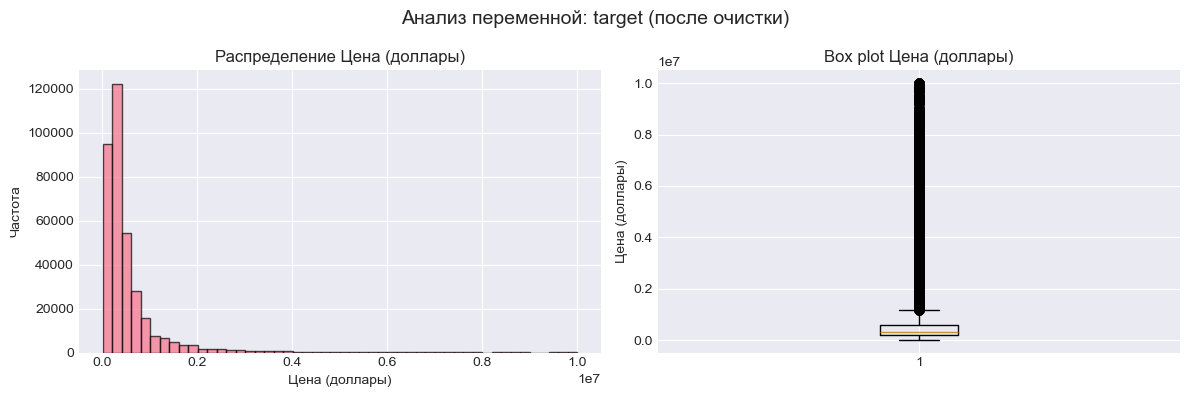


📊 TARGET (ПОСЛЕ ОЧИСТКИ):
   Единица измерения: Цена (доллары)
   min=10000.00
   max=10000000.00
   mean=577483.87
   median=329900.00
   Q1=199900.00
   Q3=592900.00
--------------------------------------------------


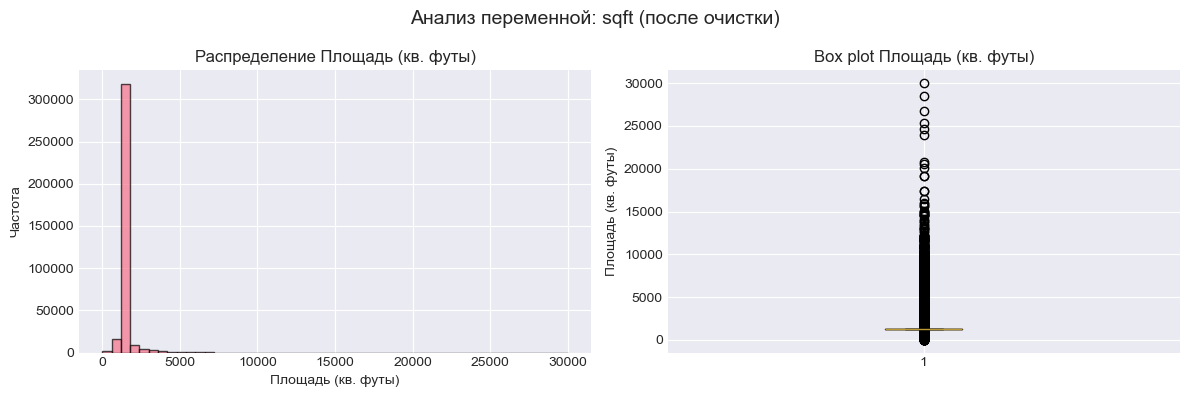


📊 SQFT (ПОСЛЕ ОЧИСТКИ):
   Единица измерения: Площадь (кв. футы)
   min=1.00
   max=30000.00
   mean=1338.98
   median=1256.00
   Q1=1256.00
   Q3=1256.00
--------------------------------------------------


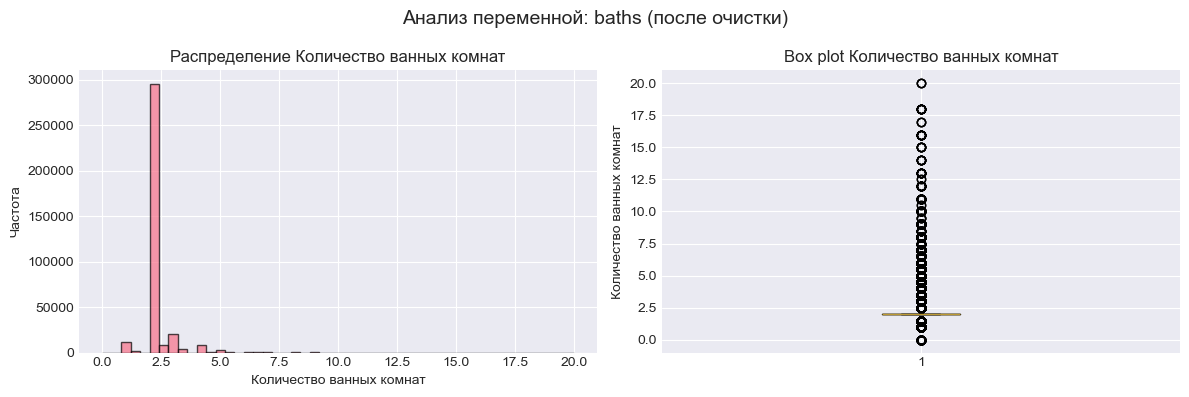


📊 BATHS (ПОСЛЕ ОЧИСТКИ):
   Единица измерения: Количество ванных комнат
   min=0.00
   max=20.00
   mean=2.16
   median=2.00
   Q1=2.00
   Q3=2.00
--------------------------------------------------


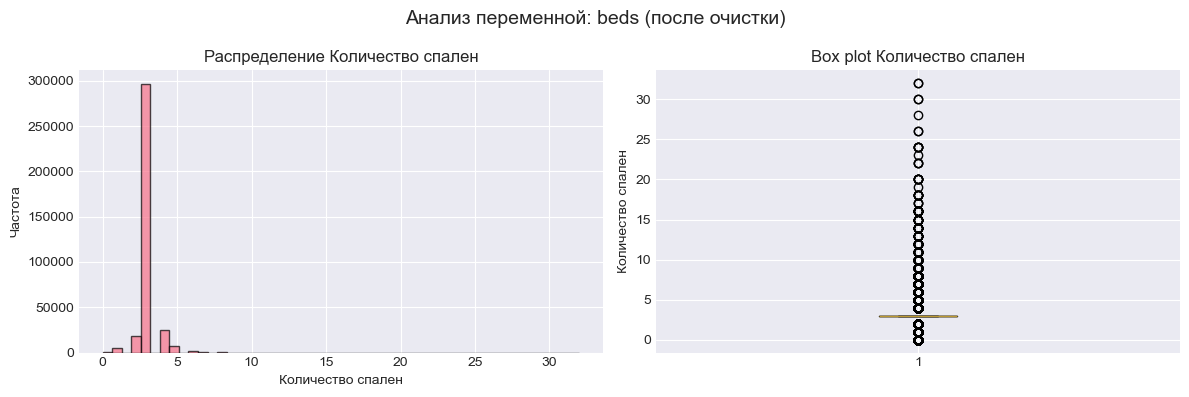


📊 BEDS (ПОСЛЕ ОЧИСТКИ):
   Единица измерения: Количество спален
   min=0.00
   max=32.00
   mean=3.06
   median=3.00
   Q1=3.00
   Q3=3.00
--------------------------------------------------


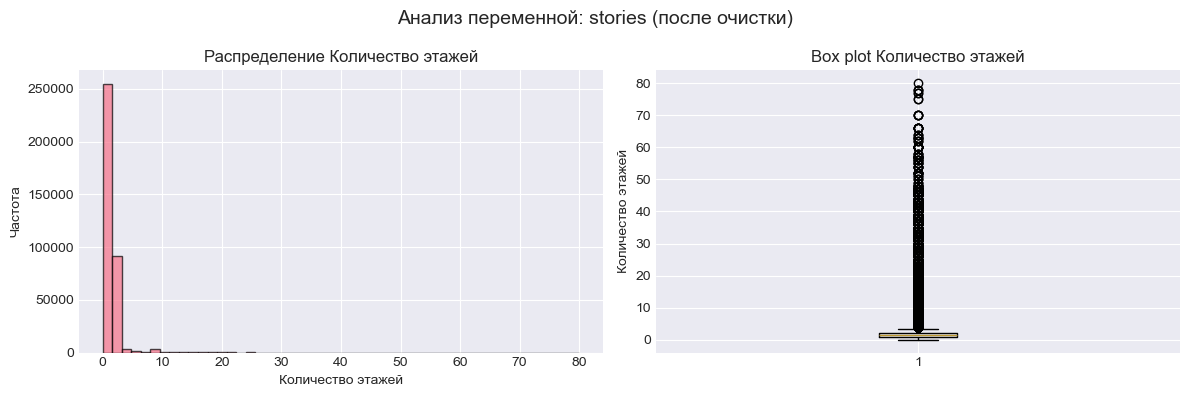


📊 STORIES (ПОСЛЕ ОЧИСТКИ):
   Единица измерения: Количество этажей
   min=0.00
   max=80.00
   mean=1.73
   median=1.50
   Q1=1.00
   Q3=2.00
--------------------------------------------------

✅ Все графики сохранены в data_processed/


In [12]:
# Визуализация распределения переменных ПОСЛЕ удаления всех аномалий

print("=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПОСЛЕ УДАЛЕНИЯ АНОМАЛИЙ ===")

# Переменные для анализа
variables = [
    {'col': 'target', 'name': 'target', 'label': 'Цена (доллары)'},
    {'col': 'sqft', 'name': 'sqft', 'label': 'Площадь (кв. футы)'},
    {'col': 'baths', 'name': 'baths', 'label': 'Количество ванных комнат'},
    {'col': 'beds', 'name': 'beds', 'label': 'Количество спален'},
    {'col': 'stories', 'name': 'stories', 'label': 'Количество этажей'}
]

for var in variables:
    col = var['col']
    name = var['name']
    label = var['label']

    if col not in df.columns:
        print(f"⚠️ {name} отсутствует в данных")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    data = df[col].dropna()

    # Гистограмма
    axes[0].hist(data, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Распределение {label}')
    axes[0].set_xlabel(label)
    axes[0].set_ylabel('Частота')

    # Box plot
    axes[1].boxplot(data, vert=True)
    axes[1].set_title(f'Box plot {label}')
    axes[1].set_ylabel(label)

    plt.suptitle(f'Анализ переменной: {name} (после очистки)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'data_processed/distribution_{name}_final.png', dpi=150)
    plt.show()

    # Статистика
    print(f"\n📊 {name.upper()} (ПОСЛЕ ОЧИСТКИ):")
    print(f"   Единица измерения: {label}")
    print(f"   min={data.min():.2f}")
    print(f"   max={data.max():.2f}")
    print(f"   mean={data.mean():.2f}")
    print(f"   median={data.median():.2f}")
    print(f"   Q1={data.quantile(0.25):.2f}")
    print(f"   Q3={data.quantile(0.75):.2f}")
    print("-" * 50)

print("\n✅ Все графики сохранены в data_processed/")

### 8. Сохранение очищенных данных для последующего использования

In [13]:
print("=== СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ ===")

# Сохраняем результат
df.to_csv('data_processed/data_cleaned_v2.csv', index=False)

print(f"✅ Сохранено data_processed/data_cleaned_v2.csv")
print(f"   Размер: {df.shape[0]:,} строк, {df.shape[1]} колонок")
print(f"\nИтоговые колонки:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

=== СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ ===
✅ Сохранено data_processed/data_cleaned_v2.csv
   Размер: 356,495 строк, 15 колонок

Итоговые колонки:
    1. status
    2. propertyType
    3. street
    4. baths
    5. homeFacts
    6. fireplace
    7. city
    8. schools
    9. sqft
   10. zipcode
   11. beds
   12. state
   13. stories
   14. target
   15. has_fireplace_info
